### Working with Large Language Models (LLMs)

#### 1. Tokens

In [ ]:
# tiktoken --> OpenAI's tokenizer library that converts text to tokens 
!uv add tiktoken 

Resolved 8 packages in 977ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 7 packages in 761ms
 + certifi==2026.6.17
 + charset-normalizer==3.4.7
 + idna==3.18
 + regex==2026.5.9
 + requests==2.34.2
 + tiktoken==0.13.0
 + urllib3==2.7.0


We can visualize the token in this site: https://platform.openai.com/tokenizer 

In [2]:
import tiktoken

text = "Which team won the FIFA World Cup in 2022?"
tokenizer = tiktoken.encoding_for_model(model_name="gpt-4o-mini") # specify the name of the model

token_ids = tokenizer.encode(text=text)
print(token_ids)

[34405, 3214, 3313, 290, 54571, 5922, 17257, 306, 220, 1323, 17, 30]


In [ ]:
# What are these numbers? We need to see actual token. 
for id in token_ids: 
    print(f"{id}-->{tokenizer.decode([id])}") 

34405-->Which
3214--> team
3313--> won
290--> the
54571--> FIFA
5922--> World
17257--> Cup
306--> in
220--> 
1323-->202
17-->2
30-->?


### 2. Embeddings

In [22]:
!uv add langchain langchain-huggingface sentence-transformers numpy pandas matplotlib scikit-learn -q

In [15]:
#loading the embedding model
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name = "Sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1343.72it/s]


In [17]:
# Lets embed some words
words = ["Cat", "Rat", "Dog", "Mat", "Computer", "Laptop"]
word_embeddings = embedding_model.embed_documents(words)
print(len(word_embeddings))

6


In [18]:
# Let's see each word embeddings
for emb in word_embeddings: 
    print("The shape of embedding:", len(emb))
    print(emb)
    print("-"*30)

The shape of embedding: 384
[0.03733033686876297, 0.0511617437005043, -0.0003060312883462757, 0.06020985171198845, -0.1174943670630455, -0.014230060391128063, 0.10577618330717087, 0.02678622677922249, 0.02633776143193245, -0.025700833648443222, -0.02349036931991577, -0.059555236250162125, -0.03021390736103058, 0.01632028818130493, -0.02907017059624195, -0.021689776331186295, -0.06624995172023773, 0.0018566425424069166, -0.024006258696317673, -0.02846253104507923, -0.046631623059511185, 0.049704764038324356, 0.003083007875829935, 0.0017626871122047305, -0.06775753945112228, 0.0761016458272934, -0.04532993957400322, -0.036434512585401535, -0.018794767558574677, -0.0591583177447319, -0.06607437133789062, -0.0003266017884016037, -0.008920368738472462, 0.05341625213623047, -0.05470171198248863, -0.051204483956098557, -0.009808597154915333, 0.0011382043594494462, 0.05640070140361786, 0.061782196164131165, -0.03502185642719269, -0.08470243960618973, -0.02723861113190651, -0.019216105341911316

In [19]:
# As we know embedding captures semantic meaning. Also similar words get similar embeddings
# Let's compute the similarity between each words now

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(word_embeddings)
print(similarity)

[[1.         0.49813383 0.66063759 0.29955303 0.40893521 0.28998904]
 [0.49813383 1.         0.50669376 0.30149006 0.3640108  0.30435981]
 [0.66063759 0.50669376 1.         0.28052988 0.42500182 0.34764457]
 [0.29955303 0.30149006 0.28052988 1.         0.36417897 0.2308089 ]
 [0.40893521 0.3640108  0.42500182 0.36417897 1.         0.71402082]
 [0.28998904 0.30435981 0.34764457 0.2308089  0.71402082 1.        ]]


In [20]:
# Making it in structured format
import pandas as pd

df = pd.DataFrame(similarity, index=words, columns=words)
df

,Cat,Rat,Dog,Mat,Computer,Laptop
Cat,1.000000,0.498134,0.660638,0.299553,0.408935,0.289989
Rat,0.498134,1.000000,0.506694,0.301490,0.364011,0.304360
Dog,0.660638,0.506694,1.000000,0.280530,0.425002,0.347645
Mat,0.299553,0.301490,0.280530,1.000000,0.364179,0.230809
Computer,0.408935,0.364011,0.425002,0.364179,1.000000,0.714021
Laptop,0.289989,0.304360,0.347645,0.230809,0.714021,1.000000


In [21]:
# Now let's visualize how similar words are grouped together
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
word_embeddings_2d = pca.fit_transform(np.array(word_embeddings))
word_embeddings_2d

array([[ 0.42045823,  0.17232114],
       [ 0.33800102,  0.04729871],
       [ 0.36318468,  0.23787515],
       [-0.03298536, -0.81341884],
       [-0.48079253,  0.11559947],
       [-0.60786603,  0.24032436]])

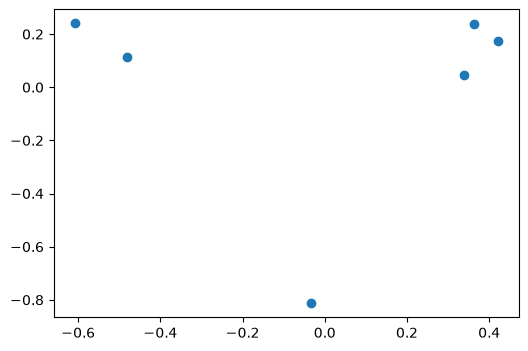

In [23]:
# Lets plot these 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(word_embeddings_2d[:,0], word_embeddings_2d[:,1])
plt.show()

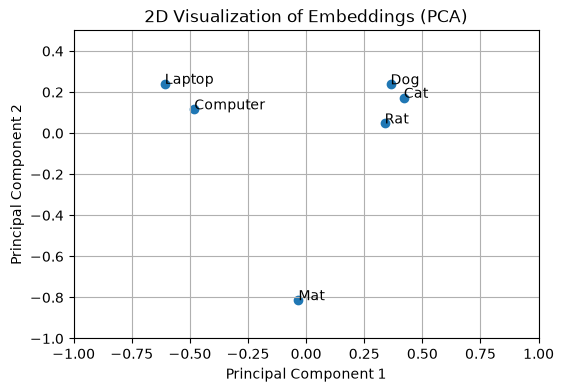

In [26]:
# Lets plot these 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(word_embeddings_2d[:,0], word_embeddings_2d[:,1])

# Adding labels
for i, word in enumerate(words): 
    plt.annotate(
        word, 
        (word_embeddings_2d[i,0], word_embeddings_2d[i,1])
    )

plt.title("2D Visualization of Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.xlim(-1,1)
plt.ylim(-1,0.5)
plt.grid(True)
plt.show()

_**🎉 We can see in the figure, word having similar meaning are grouped together, while words with different meaning are far from each other.**_

### 3. Loading the Text Generation Model (LLM)

In [ ]:
! uv add langchain-openai -q

In [43]:
import os
from dotenv import load_dotenv 

load_dotenv(override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_BASE_URL = "https://api.groq.com/openai/v1"

In [44]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="llama-3.1-8b-instant", 
    api_key=GROQ_API_KEY, 
    base_url=GROQ_BASE_URL
)

In [45]:
# We have loaded out model, let's have a convo

response = model.invoke("Hi there!")
print(response.content)

It's nice to meet you. Is there something I can help you with, or would you like to chat?


### 4. Controlling the Model Output

#### 4.1 Temperature

In [46]:
model = ChatOpenAI(
    model="llama-3.1-8b-instant", 
    temperature = 1.5, # Temperature can range between 0 < temp <= 2 depending upon the model
    api_key=GROQ_API_KEY, 
    base_url=GROQ_BASE_URL
)

In [48]:
response = model.invoke("Create a funny joke about chickens.")
print(response.content)

A chicken walks into a library and asks the librarian, "Do you have any eggs-perts in here?" The librarian rolls her eyes and says, "Check the fowl section."


#### 4.2 top_p

In [61]:
model = ChatOpenAI(
    model="llama-3.1-8b-instant", 
    temperature=2,
    top_p = 1, # the value ranges from 0 to 1 (this is cumulative probability)
    api_key=GROQ_API_KEY, 
    base_url=GROQ_BASE_URL
)

In [63]:
response = model.invoke("Create a funny joke about chickens.")
print(response.content)

Why did the chicken go to the gym?

Because it wanted to pump up its egg-cellence and fowl its diet for the buff-ter months.


### 5. Let's build a simple chatbot

In [65]:
! uv add gradio -q

In [ ]:
import gradio as gr

def chatbot(message, history=[]): 
    response = model.invoke(message).content
    return response

gr.ChatInterface(fn = chatbot, title="LLM Chatbot").launch(inbrowser=True)

In [75]:
# Let's make it like Chatgpt (Adding streaming Mode)

import warnings
warnings.filterwarnings("ignore")

def chatbot(message, history=[]): 
    # response = model.invoke(message).content
    response = model.stream(message)
    

    full_response = ""
    for chunk in response: 
        if chunk.content: 
            full_response += chunk.content
            yield full_response

gr.ChatInterface(fn = chatbot, title="LLM Chatbot").launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
